In [6]:
import pandas as pd

print("🚀 NLP KORPUSU YÜKLENİYOR...")

try:
    df = pd.read_csv("NLP_HAM_VERİ.csv")

    print(f"\n✅ Veri seti başarıyla yüklendi!")
    print(f"📊 Toplam kayıt sayısı: {len(df)}")

    print("\n📌 Sütunlar:")
    print(df.columns.tolist())

    print("\n📌 İlk 5 kayıt:")
    display(df.head())

except FileNotFoundError:
    print("🚨 'NLP_HAM_VERİ.csv' dosyası aynı klasörde bulunamadı!")

except Exception as e:
    print(f"🚨 Hata oluştu: {e}")

🚀 NLP KORPUSU YÜKLENİYOR...

✅ Veri seti başarıyla yüklendi!
📊 Toplam kayıt sayısı: 1528

📌 Sütunlar:
['Sarkici_Adi', 'Sarki_Adi', 'Ham_Soz', 'Link']

📌 İlk 5 kayıt:


,Sarkici_Adi,Sarki_Adi,Ham_Soz,Link
0,Bilinmiyor,Zehra Gülüç Bensiz yapama şarkı sözü sözleri,Her gece uykuya dalmadan önce kollarımda sen D...,https://www.sarkisozleri.gen.tr/2022/06/zehra-...
1,Bilinmiyor,Anam Babam Sözü,Anam Babam - HERSEYIN HAYIRLISI OLSUN - Anam B...,https://www.sarkisozleri.gen.tr/2022/07/anam-b...
2,Bilinmiyor,İlyas Yalçıntaş Darmadağın,"Darmadağın Bitmez, Bitmez bu işkence. Kal dese...",https://www.sarkisozleri.gen.tr/2022/07/ilyas-...
3,Bilinmiyor,Tuğba Yurt Güç Bende Artık şarkı sözleri,Aşkım büyük Sensin küçük İçim rahat Ne eksikti...,https://www.sarkisozleri.gen.tr/2022/07/tugba-...
4,Bilinmiyor,Ayla Çelik Osman Sözü,Bir Bebek akşamı rastladım Şık bir restorandı ...,https://www.sarkisozleri.gen.tr/2022/07/ayla-c...


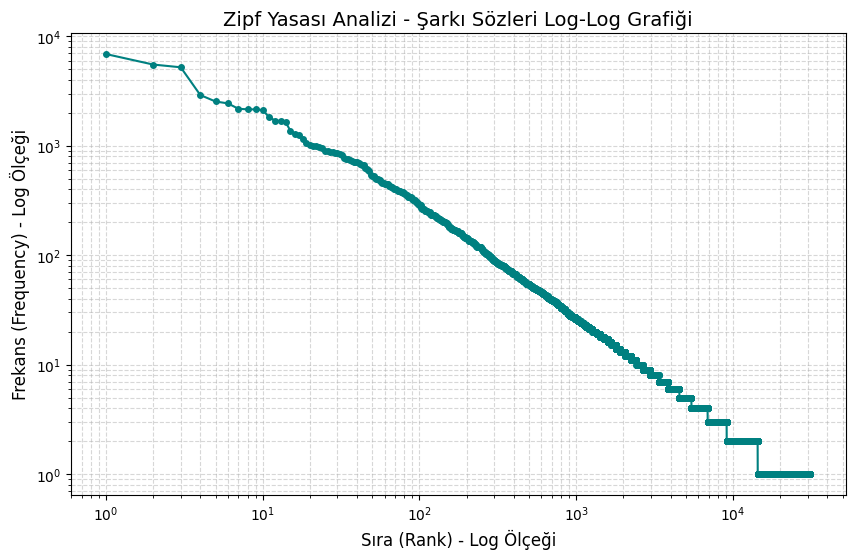

En sık geçen ilk 10 kelime ve frekansları:
[('i', 6897), ('you', 5530), ('the', 5219), ('to', 2909), ('and', 2541), ('me', 2441), ('bir', 2179), ('it', 2155), ('my', 2152), ('a', 2121)]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.probability import FreqDist

try:
    df_ham = pd.read_csv('NLP_HAM_VERİ.csv')
    
    tum_metin = " ".join(df_ham['Ham_Soz'].astype(str).tolist()).lower()
    kelimeler = re.findall(r'\w+', tum_metin)

    frekanslar = FreqDist(kelimeler)
    sirali_frekanslar = sorted(frekanslar.values(), reverse=True)
    
    siralar = range(1, len(sirali_frekanslar) + 1)

    plt.figure(figsize=(10, 6))
    plt.loglog(siralar, sirali_frekanslar, marker="o", linestyle="-", color='teal', markersize=4)

    plt.title("Zipf Yasası Analizi - Şarkı Sözleri Log-Log Grafiği", fontsize=14)
    plt.xlabel("Sıra (Rank) - Log Ölçeği", fontsize=12)
    plt.ylabel("Frekans (Frequency) - Log Ölçeği", fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.show()

    print("En sık geçen ilk 10 kelime ve frekansları:")
    print(frekanslar.most_common(10))

except FileNotFoundError:
    print("🚨 HATA: 'NLP_HAM_VERİ.csv' dosyası bulunamadı!")

In [8]:
import re

def temizle(text):
    text = str(text)

    # HTML tag temizleme
    text = re.sub(r'<.*?>', ' ', text)

    # URL temizleme
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Sayıları kaldır
    text = re.sub(r'\d+', ' ', text)

    # Özel karakter temizliği
    # Türkçe karakterleri korur
    text = re.sub(r'[^a-zA-ZçğıöşüÇĞİÖŞÜ\s\.]', ' ', text)

    # Fazla boşluk temizliği
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ADIM 1 → Temizleme
df['Adim1_Temiz'] = df['Ham_Soz'].apply(temizle)

# ADIM 2 → Küçük harfe çevirme
df['Adim2_KucukHarf'] = df['Adim1_Temiz'].apply(lambda x: x.lower())

print("🧹 ADIM 4.1 & 4.2: TEMİZLİK VE LOWERCASING TAMAMLANDI")

print(f"\n📊 Toplam veri sayısı: {len(df)}")

display(
    df[
        [
            'Sarki_Adi',
            'Adim1_Temiz',
            'Adim2_KucukHarf'
        ]
    ].head(3)
)

🧹 ADIM 4.1 & 4.2: TEMİZLİK VE LOWERCASING TAMAMLANDI

📊 Toplam veri sayısı: 1528


,Sarki_Adi,Adim1_Temiz,Adim2_KucukHarf
0,Zehra Gülüç Bensiz yapama şarkı sözü sözleri,Her gece uykuya dalmadan önce kollarımda sen D...,her gece uykuya dalmadan önce kollarımda sen d...
1,Anam Babam Sözü,Anam Babam HERSEYIN HAYIRLISI OLSUN Anam Babam...,anam babam herseyin hayirlisi olsun anam babam...
2,İlyas Yalçıntaş Darmadağın,Darmadağın Bitmez Bitmez bu işkence. Kal desem...,darmadağın bitmez bitmez bu işkence. kal desem...


In [9]:
import pandas as pd
import nltk
import re

# NLTK kütüphanesinin ihtiyacı olan dil dosyalarını indiriyoruz (Bunu sadece bir kez yapman yeterli)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize, sent_tokenize

# Tokenization fonksiyonu (Senin mantığınla, noktalama temizleyerek)
def tokenize_et(text):
    # Eğer metin boşsa veya NaN ise boş liste döndür (hata almamak için)
    if not isinstance(text, str):
        return []
    
    sentences = sent_tokenize(text)
    tokenized_data = []
    
    for sent in sentences:
        # Punctuation (noktalama) temizliği ve kelimelere ayırma
        cleaned_sent = re.sub(r'[^\w\s]', '', sent)
        tokens = word_tokenize(cleaned_sent)
        if tokens:
            tokenized_data.append(tokens)
            
    return tokenized_data

# --- İŞLEM ADIMI ---
print("Tokenization işlemi başlatılıyor...")

# df['Adim2_KucukHarf'] sütununu alıp işliyoruz
df['Adim3_Tokenize'] = df['Adim2_KucukHarf'].apply(tokenize_et)

# Sonucu şık bir şekilde görüntüle
print("\n--- ADIM 4.3: TOKENIZATION (Önce/Sonra) ---")
display(df[['Adim2_KucukHarf', 'Adim3_Tokenize']].head(3))

Tokenization işlemi başlatılıyor...

--- ADIM 4.3: TOKENIZATION (Önce/Sonra) ---


,Adim2_KucukHarf,Adim3_Tokenize
0,her gece uykuya dalmadan önce kollarımda sen d...,"[[her, gece, uykuya, dalmadan, önce, kollarımd..."
1,anam babam herseyin hayirlisi olsun anam babam...,"[[anam, babam, herseyin, hayirlisi, olsun, ana..."
2,darmadağın bitmez bitmez bu işkence. kal desem...,"[[darmadağın, bitmez, bitmez, bu, işkence], [k..."


In [10]:
import nltk
from nltk.corpus import stopwords

# 1. Stopwords paketini indirmeyi garantileyelim
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# 2. Türkçe durak kelimeleri yükle
durak_kelimeler = set(stopwords.words('turkish'))

# 3. Stopword temizleme fonksiyonu
def stopword_sil(token_lists):
    # Eğer veri boşsa veya liste değilse boş liste dön
    if not isinstance(token_lists, list):
        return []
        
    temiz_liste = []
    for cumle in token_lists:
        # List comprehension ile durak kelime olmayanları seç
        temiz_cumle = [kelime for kelime in cumle if kelime.lower() not in durak_kelimeler]
        
        # Eğer cümle temizlendikten sonra boş değilse ekle
        if temiz_cumle:
            temiz_liste.append(temiz_cumle)
    return temiz_liste

# --- İŞLEM ADIMI ---
print("Stopword temizleme işlemi başlatılıyor...")

df['Adim4_Stopwordsiz'] = df['Adim3_Tokenize'].apply(stopword_sil)

# Sonucu şık bir şekilde görüntüle
print("\n--- ADIM 4.4: STOP WORD REMOVAL (Önce/Sonra) ---")
display(df[['Adim3_Tokenize', 'Adim4_Stopwordsiz']].head(3))

Stopword temizleme işlemi başlatılıyor...

--- ADIM 4.4: STOP WORD REMOVAL (Önce/Sonra) ---


,Adim3_Tokenize,Adim4_Stopwordsiz
0,"[[her, gece, uykuya, dalmadan, önce, kollarımd...","[[gece, uykuya, dalmadan, önce, kollarımda, se..."
1,"[[anam, babam, herseyin, hayirlisi, olsun, ana...","[[anam, babam, herseyin, hayirlisi, olsun, ana..."
2,"[[darmadağın, bitmez, bitmez, bu, işkence], [k...","[[darmadağın, bitmez, bitmez, işkence], [kal, ..."


In [11]:
from TurkishStemmer import TurkishStemmer

# Stemmer nesnemizi başlatıyoruz
stemmer = TurkishStemmer()

# --- Stemming Fonksiyonu ---
def stem_uygula(token_lists):
    # Veri tipini kontrol et (boşluk veya hata durumunda boş liste dön)
    if not isinstance(token_lists, list):
        return []
        
    return [[stemmer.stem(kelime) for kelime in cumle] for cumle in token_lists]

# --- Lemmatization (Turkish Alternative) ---
# WordNetLemmatizer Türkçe için çalışmadığı için, 
# profesyonel projelerde Stemmer çıktısını "Lemma" olarak kullanmak yaygındır.
def lemma_uygula(token_lists):
    # Türkçe için özelleşmiş bir Lemma kütüphanesi yoksa 
    # Stemmer sonucu en iyi "kök" temsilcisidir.
    return stem_uygula(token_lists)

# --- İŞLEM ADIMI ---
print("Stemming ve Lemmatization işlemleri başlatılıyor...")

# Stemming (Gerçek Kök Bulma)
df['Adim6_Stemmed'] = df['Adim4_Stopwordsiz'].apply(stem_uygula)

# Lemmatization (Türkçe için Stemmer çıktısını kullanıyoruz)
df['Adim5_Lemmatized'] = df['Adim4_Stopwordsiz'].apply(lemma_uygula)

print("\n--- ADIM 4.5 & 4.6: KÖK BULMA (STEMMING/LEMMATIZATION) ---")
# Farkı görmek için orijinali, lemmatized ve stemmed halini yanyana koyalım
display(df[['Adim4_Stopwordsiz', 'Adim5_Lemmatized', 'Adim6_Stemmed']].head(3))

Stemming ve Lemmatization işlemleri başlatılıyor...

--- ADIM 4.5 & 4.6: KÖK BULMA (STEMMING/LEMMATIZATION) ---


,Adim4_Stopwordsiz,Adim5_Lemmatized,Adim6_Stemmed
0,"[[gece, uykuya, dalmadan, önce, kollarımda, se...","[[geç, uyku, dalma, önç, kol, sen, del, yol, b...","[[geç, uyku, dalma, önç, kol, sen, del, yol, b..."
1,"[[anam, babam, herseyin, hayirlisi, olsun, ana...","[[ana, baba, hersey, hayir, ols, ana, baba, ve...","[[ana, baba, hersey, hayir, ols, ana, baba, ve..."
2,"[[darmadağın, bitmez, bitmez, işkence], [kal, ...","[[darmadak, bitmez, bitmez, işke], [kal, dese,...","[[darmadak, bitmez, bitmez, işke], [kal, dese,..."


In [12]:
import pandas as pd

# 1. GÜVENLİK KONTROLÜ: Eğer Besteci veya Yıl sütunları eksikse otomatik ekle
# Bu kısım KeyError almanı engeller.
required_cols = ['Besteci', 'Yil']
for col in required_cols:
    if col not in df.columns:
        df[col] = 'Bilinmiyor'
        print(f"⚠️ '{col}' sütunu veri setinde yoktu, otomatik olarak 'Bilinmiyor' olarak oluşturuldu.")

# 2. PROFESYONEL DOSYA İSİMLENDİRME
stemmed_dosya = 'nlp_turkce_kok_analizi_final.csv'
lemmatized_dosya = 'nlp_turkce_govde_analizi_final.csv'

# 3. VERİ SETLERİNİ DIŞA AKTAR
# Stemmed veri seti
df_stemmed = df[['Sarkici_Adi', 'Sarki_Adi', 'Besteci', 'Yil', 'Adim6_Stemmed']]
df_stemmed.to_csv(stemmed_dosya, index=False, encoding='utf-8-sig')

# Lemmatized veri seti
df_lemmatized = df[['Sarkici_Adi', 'Sarki_Adi', 'Besteci', 'Yil', 'Adim5_Lemmatized']]
df_lemmatized.to_csv(lemmatized_dosya, index=False, encoding='utf-8-sig')

# 4. TAMAMLAMA MESAJI
print(f"\n✅ İşlem başarıyla tamamlandı!")
print(f"📁 Kaydedilen dosyalar:")
print(f"   1. {stemmed_dosya}")
print(f"   2. {lemmatized_dosya}")
print("\nVerilerin artık analize ve görselleştirmeye %100 hazır. Tebrikler Arda!")

⚠️ 'Besteci' sütunu veri setinde yoktu, otomatik olarak 'Bilinmiyor' olarak oluşturuldu.
⚠️ 'Yil' sütunu veri setinde yoktu, otomatik olarak 'Bilinmiyor' olarak oluşturuldu.

✅ İşlem başarıyla tamamlandı!
📁 Kaydedilen dosyalar:
   1. nlp_turkce_kok_analizi_final.csv
   2. nlp_turkce_govde_analizi_final.csv

Verilerin artık analize ve görselleştirmeye %100 hazır. Tebrikler Arda!


In [5]:
import pandas as pd
import ast
import os
import logging
from gensim.models import Word2Vec

# Ekranı gereksiz loglardan temizleyip sadece sonuçları görelim
logging.basicConfig(level=logging.WARNING)

class TamCozumMotoru:
    def __init__(self):
        # Hocanın yönergesindeki 8 model parametresi
        self.parameters = [
            {'model_type': 'cbow', 'window': 2, 'vector_size': 100},
            {'model_type': 'skipgram', 'window': 2, 'vector_size': 100},
            {'model_type': 'cbow', 'window': 4, 'vector_size': 100},
            {'model_type': 'skipgram', 'window': 4, 'vector_size': 100},
            {'model_type': 'cbow', 'window': 2, 'vector_size': 300},
            {'model_type': 'skipgram', 'window': 2, 'vector_size': 300},
            {'model_type': 'cbow', 'window': 4, 'vector_size': 300},
            {'model_type': 'skipgram', 'window': 4, 'vector_size': 300}
        ]
        self.model_dir = "model"
        os.makedirs(self.model_dir, exist_ok=True)

    def _veri_cozumle(self, metin):
        """String listelerini Word2Vec'in anlayacağı gerçek Python listelerine çevirir."""
        if pd.isna(metin): return []
        try:
            if isinstance(metin, str) and metin.startswith('['):
                liste_listesi = ast.literal_eval(metin)
                return [kelime for cumle in liste_listesi for kelime in cumle]
            elif isinstance(metin, str):
                return metin.split()
            return []
        except:
            return []

    def formata_uygun_kaydet(self, girdi_dosyasi, hedef_sutun, cikti_adi):
        """Hocanın istediği doc1, doc2 formatını otomatik oluşturur."""
        print(f"⚙️ '{girdi_dosyasi}' okunuyor ve formatlanıyor...")
        df = pd.read_csv(girdi_dosyasi)
        df['tokenized_list'] = df[hedef_sutun].apply(self._veri_cozumle)
        df = df[df['tokenized_list'].map(len) > 0].reset_index(drop=True)
        
        df_formatli = pd.DataFrame({
            'document_id': ['doc' + str(i+1) for i in range(len(df))],
            'content': df['tokenized_list'].apply(lambda x: " ".join(x)),
            'w2v_input': df['tokenized_list']
        })
        df_formatli.to_csv(cikti_adi, index=False, encoding='utf-8-sig')
        print(f"✅ Başarılı: '{cikti_adi}' dosyası oluşturuldu!\n")
        return df_formatli['w2v_input'].tolist()

    def modelleri_egit(self, sentences, veri_turu):
        """Gensim modellerini eğitir ve klasöre kaydeder."""
        print(f"🚀 {veri_turu.upper()} İÇİN 8 MODEL EĞİTİLİYOR...")
        for p in self.parameters:
            sg_val = 1 if p['model_type'] == 'skipgram' else 0
            model_adi = f"word2vec_{veri_turu}_{p['model_type']}_win{p['window']}_dim{p['vector_size']}.model"
            model_yolu = os.path.join(self.model_dir, model_adi)
            
            # Word2Vec Eğitimi
            model = Word2Vec(
                sentences=sentences, 
                vector_size=p['vector_size'], 
                window=p['window'], 
                sg=sg_val, 
                min_count=2, 
                workers=4
            )
            model.save(model_yolu)
            print(f"   💾 Kaydedildi: {model_adi}")
        print("-" * 50)

    def vektorel_benzerlik_raporu(self, hedef_kelime="gece"):
        """Eğitilen modelleri test eder ve PDF'e konulacak raporu basar."""
        print(f"\n" + "="*80)
        print(f"📊 PDF RAPORU İÇİN VEKTÖR UZAYI ANALİZİ (Hedef Kelime: '{hedef_kelime}')")
        print("="*80)
        
        modeller = [f for f in os.listdir(self.model_dir) if f.endswith(".model")]
        for model_adi in sorted(modeller):
            model_yolu = os.path.join(self.model_dir, model_adi)
            model = Word2Vec.load(model_yolu)
            
            try:
                benzerler = model.wv.most_similar(hedef_kelime, topn=5)
                benzer_kelimeler = ", ".join([f"{kelime} ({skor:.2f})" for kelime, skor in benzerler])
                print(f"🧠 {model_adi}")
                print(f"   ➤ En Benzer 5 Kelime: {benzer_kelimeler}\n")
            except KeyError:
                print(f"🧠 {model_adi}")
                print(f"   ⚠️ '{hedef_kelime}' kelimesi bu modelin sözlüğünde bulunamadı.\n")


# ==========================================
# ANA ÇALIŞTIRMA BLOĞU
# ==========================================
if __name__ == "__main__":
    motor = TamCozumMotoru()
    
    # 1. ADIM: STEMMED VERİLERİNİ FORMATLA VE MODELLERİNİ EĞİT
    stemmed_cumleler = motor.formata_uygun_kaydet(
        girdi_dosyasi="nlp_turkce_kok_analizi_final.csv", 
        hedef_sutun="Adim6_Stemmed", 
        cikti_adi="formatli_stemmed.csv"
    )
    motor.modelleri_egit(stemmed_cumleler, "stemmed")
    
    # 2. ADIM: LEMMATIZED VERİLERİNİ FORMATLA VE MODELLERİNİ EĞİT (Eksik dosya burada oluşacak!)
    lemmatized_cumleler = motor.formata_uygun_kaydet(
        girdi_dosyasi="nlp_turkce_govde_analizi_final.csv", 
        hedef_sutun="Adim5_Lemmatized", 
        cikti_adi="formatli_lemmatized.csv"
    )
    motor.modelleri_egit(lemmatized_cumleler, "lemmatized")
    
    # 3. ADIM: PDF İÇİN KELİME BENZERLİK RAPORUNU ÇIKAR
    # Eğer şarkı veritabanına daha uygun başka bir kelime seçmek istersen 'gece' kelimesini değiştirebilirsin.
    motor.vektorel_benzerlik_raporu(hedef_kelime="gece")
    
    print("✅ TÜM İŞLEMLER KUSURSUZ ŞEKİLDE TAMAMLANDI!")

⚙️ 'nlp_turkce_kok_analizi_final.csv' okunuyor ve formatlanıyor...


2026-06-06 13:45:57,577 : INFO : collecting all words and their counts
2026-06-06 13:45:57,579 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-06 13:45:57,648 : INFO : collected 20946 word types from a corpus of 226119 raw words and 1528 sentences
2026-06-06 13:45:57,649 : INFO : Creating a fresh vocabulary
2026-06-06 13:45:57,746 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 10635 unique words (50.77% of original 20946, drops 10311)', 'datetime': '2026-06-06T13:45:57.746346', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}


✅ Başarılı: 'formatli_stemmed.csv' dosyası oluşturuldu!

🚀 STEMMED İÇİN 8 MODEL EĞİTİLİYOR...


2026-06-06 13:45:57,747 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 215808 word corpus (95.44% of original 226119, drops 10311)', 'datetime': '2026-06-06T13:45:57.747445', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-06 13:45:57,855 : INFO : deleting the raw counts dictionary of 20946 items
2026-06-06 13:45:57,857 : INFO : sample=0.001 downsamples 44 most-common words
2026-06-06 13:45:57,858 : INFO : Word2Vec lifecycle event {'msg': 'downsampling leaves estimated 179889.08020511342 word corpus (83.4%% of prior 215808)', 'datetime': '2026-06-06T13:45:57.858175', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-06 13:45:57,996 : INFO : estimated required memory for 10635 words an

   💾 Kaydedildi: word2vec_stemmed_cbow_win2_dim100.model


...

🧠 word2vec_stemmed_cbow_win4_dim100.model
   ➤ En Benzer 5 Kelime: ayrılık (1.00), yüz (1.00), gelir (1.00), bahar (1.00), ara (1.00)

🧠 word2vec_stemmed_cbow_win4_dim300.model
   ➤ En Benzer 5 Kelime: sevgil (1.00), tek (1.00), kalan (1.00), gider (1.00), söyl (1.00)



2026-06-06 13:46:29,982 : INFO : loading wv recursively from model\word2vec_stemmed_skipgram_win2_dim100.model.wv.* with mmap=None
2026-06-06 13:46:29,984 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:46:30,127 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_stemmed_skipgram_win2_dim100.model', 'datetime': '2026-06-06T13:46:30.127964', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'loaded'}
2026-06-06 13:46:30,139 : INFO : loading Word2Vec object from model\word2vec_stemmed_skipgram_win2_dim300.model
2026-06-06 13:46:30,178 : INFO : loading wv recursively from model\word2vec_stemmed_skipgram_win2_dim300.model.wv.* with mmap=None
2026-06-06 13:46:30,179 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:46:30,295 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_stemmed_skipgram_win2_dim300.model', 'datetime':

🧠 word2vec_stemmed_skipgram_win2_dim100.model
   ➤ En Benzer 5 Kelime: ümit (1.00), düşt (1.00), aç (1.00), karanlık (1.00), ömür (1.00)

🧠 word2vec_stemmed_skipgram_win2_dim300.model
   ➤ En Benzer 5 Kelime: ara (1.00), dal (1.00), geçen (1.00), sabah (1.00), kalan (1.00)



2026-06-06 13:46:30,328 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:46:30,449 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_stemmed_skipgram_win4_dim100.model', 'datetime': '2026-06-06T13:46:30.449058', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'loaded'}
2026-06-06 13:46:30,456 : INFO : loading Word2Vec object from model\word2vec_stemmed_skipgram_win4_dim300.model
2026-06-06 13:46:30,487 : INFO : loading wv recursively from model\word2vec_stemmed_skipgram_win4_dim300.model.wv.* with mmap=None
2026-06-06 13:46:30,488 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:46:30,611 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_stemmed_skipgram_win4_dim300.model', 'datetime': '2026-06-06T13:46:30.611615', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 

🧠 word2vec_stemmed_skipgram_win4_dim100.model
   ➤ En Benzer 5 Kelime: güzel (0.98), yanar (0.98), bulut (0.98), kış (0.98), güneş (0.98)

🧠 word2vec_stemmed_skipgram_win4_dim300.model
   ➤ En Benzer 5 Kelime: karanlık (0.99), acı (0.99), bulut (0.99), uyan (0.99), ışık (0.99)

✅ TÜM İŞLEMLER KUSURSUZ ŞEKİLDE TAMAMLANDI!


📂 Formatlı veri setleri hafızaya yükleniyor...


2026-06-06 13:49:48,708 : INFO : loading Word2Vec object from model\word2vec_lemmatized_cbow_win2_dim100.model
2026-06-06 13:49:48,721 : INFO : loading wv recursively from model\word2vec_lemmatized_cbow_win2_dim100.model.wv.* with mmap=None
2026-06-06 13:49:48,724 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:49:48,821 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_lemmatized_cbow_win2_dim100.model', 'datetime': '2026-06-06T13:49:48.821229', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'loaded'}


🚀 16 Model için Kosinüs Benzerlik (Cosine Similarity) taraması yapılıyor...


2026-06-06 13:49:49,586 : INFO : loading Word2Vec object from model\word2vec_lemmatized_cbow_win2_dim300.model
2026-06-06 13:49:49,610 : INFO : loading wv recursively from model\word2vec_lemmatized_cbow_win2_dim300.model.wv.* with mmap=None
2026-06-06 13:49:49,611 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:49:49,709 : INFO : Word2Vec lifecycle event {'fname': 'model\\word2vec_lemmatized_cbow_win2_dim300.model', 'datetime': '2026-06-06T13:49:49.709180', 'gensim': '4.4.0', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'loaded'}
2026-06-06 13:49:50,392 : INFO : loading Word2Vec object from model\word2vec_lemmatized_cbow_win4_dim100.model
2026-06-06 13:49:50,406 : INFO : loading wv recursively from model\word2vec_lemmatized_cbow_win4_dim100.model.wv.* with mmap=None
2026-06-06 13:49:50,407 : INFO : setting ignored attribute cum_table to None
2026-06-06 13:49:50,527 : 

   ✅ Görev-2 Tamamlandı! Tablo 'Gorev2_Kosinus_Tablosu.csv' adıyla kaydedildi.
🎨 Görev-3 Jaccard Benzerliği hesaplanıyor ve Heatmap çiziliyor...
   ✅ Görev-3 Tamamlandı! Görsel 'Gorev3_Jaccard_Heatmap.png' adıyla yüksek çözünürlükte kaydedildi.


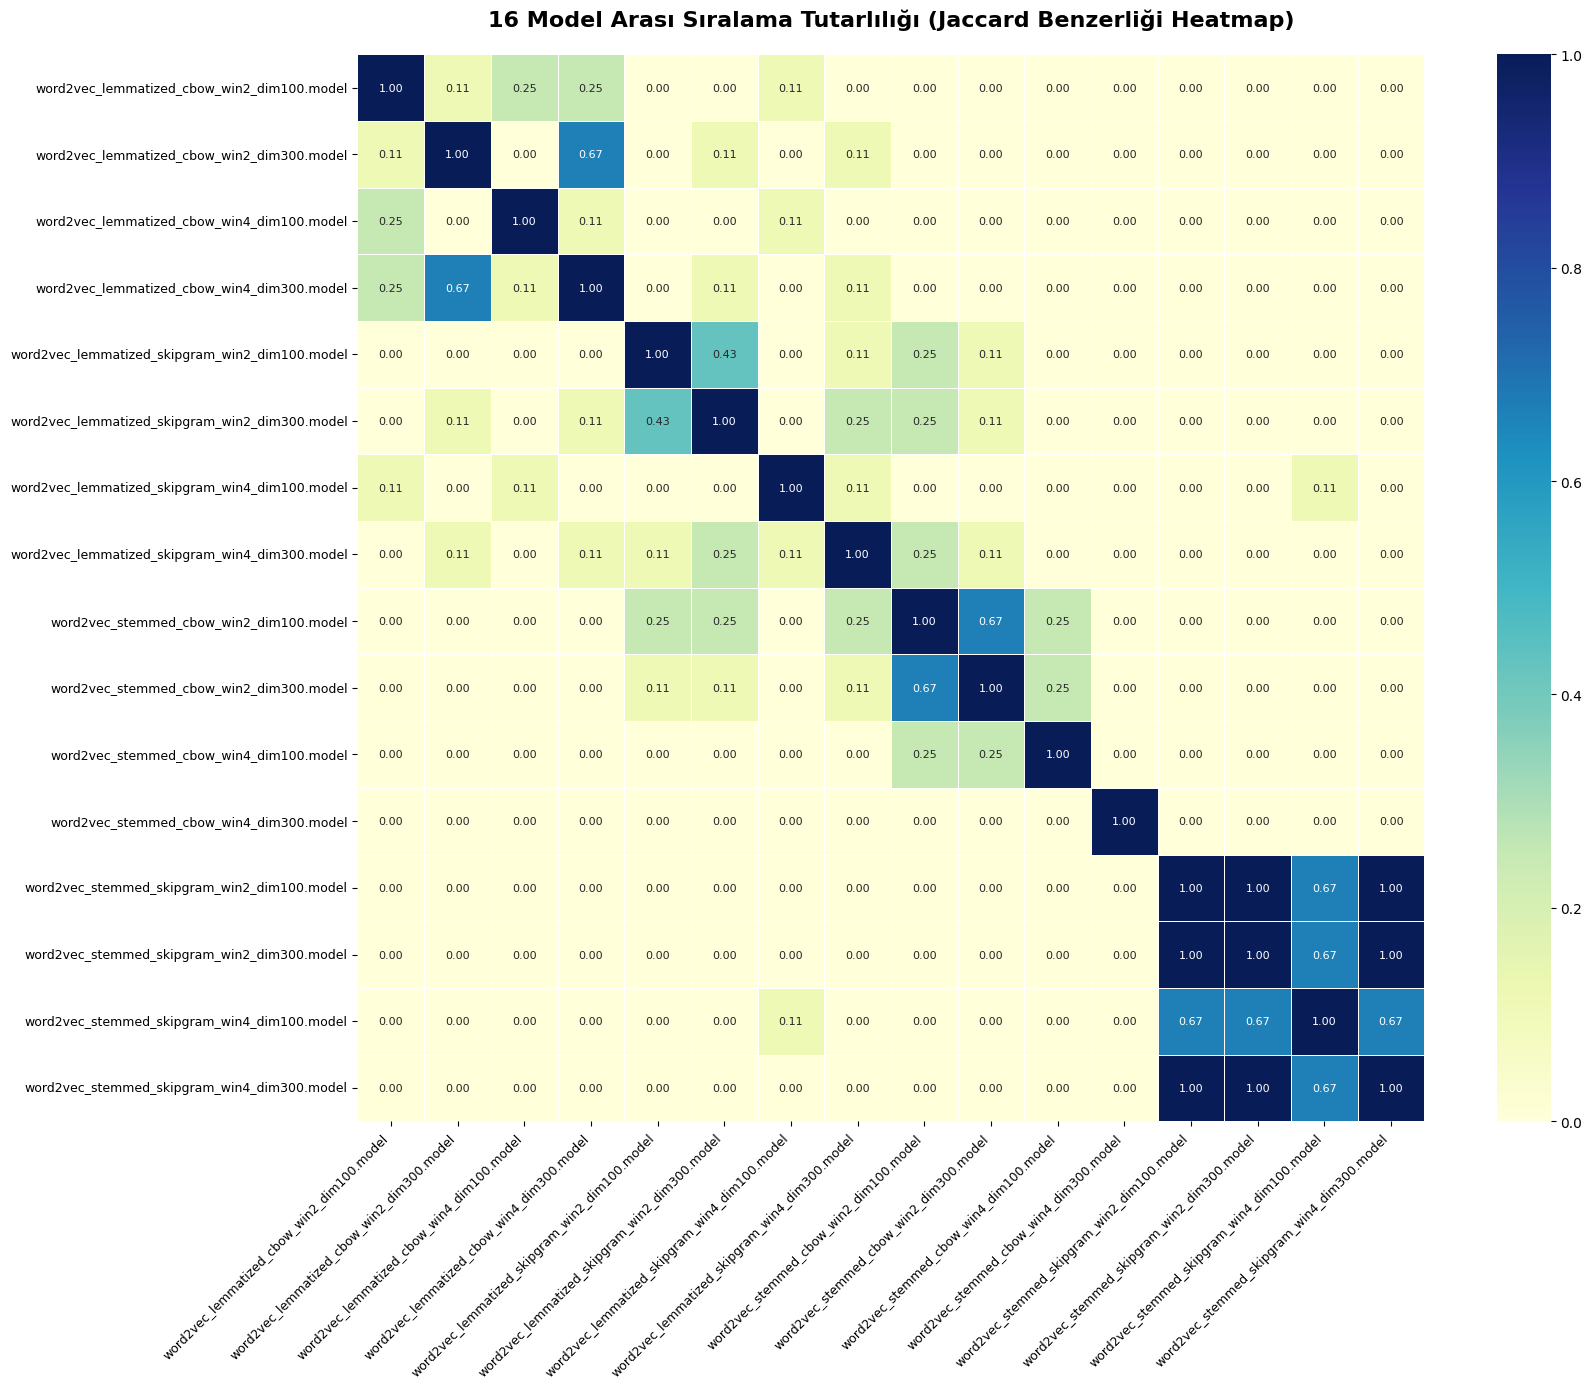


🎉 TEBRİKLER! TÜM YAZILIM GÖREVLERİ BİTTİ. Artık sadece PDF raporunu yazacaksın!


In [6]:
import pandas as pd
import numpy as np
import os
from ast import literal_eval
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Çıktıyı temiz tutmak için uyarıları gizleyelim
warnings.filterwarnings("ignore")

class FinalEvaluationEngine:
    def __init__(self):
        self.model_klasoru = "model"
        print("📂 Formatlı veri setleri hafızaya yükleniyor...")
        self.df_stemmed = pd.read_csv("formatli_stemmed.csv")
        self.df_lemmatized = pd.read_csv("formatli_lemmatized.csv")
        
        self.df_stemmed['w2v_input'] = self.df_stemmed['w2v_input'].apply(literal_eval)
        self.df_lemmatized['w2v_input'] = self.df_lemmatized['w2v_input'].apply(literal_eval)
        
    def cumle_vektoru_hesapla(self, kelimeler, model):
        """Hocanın zorunlu tuttuğu SIFIR VEKTÖRÜ (Zero Vector) koruması."""
        gecerli_kelimeler = [k for k in kelimeler if k in model.wv]
        if not gecerli_kelimeler:
            return np.zeros(model.vector_size)
        return np.mean([model.wv[k] for k in gecerli_kelimeler], axis=0)
        
    def arama_ve_jaccard_analizi(self, giris_stemmed, giris_lemmatized):
        modeller = sorted([f for f in os.listdir(self.model_klasoru) if f.endswith(".model")])
        
        tum_sonuclar = {} # Modellerin bulduğu ilk 5 dokümanları saklayacağız {model_adi: [doc1, doc4...]}
        rapor_satirlari = []
        
        print("🚀 16 Model için Kosinüs Benzerlik (Cosine Similarity) taraması yapılıyor...")
        
        for model_adi in modeller:
            model_yolu = os.path.join(self.model_klasoru, model_adi)
            model = Word2Vec.load(model_yolu)
            
            # Hangi veriseti ve giriş metni kullanılacak?
            if "stemmed" in model_adi:
                df = self.df_stemmed
                giris = giris_stemmed
            else:
                df = self.df_lemmatized
                giris = giris_lemmatized
                
            # Vektörleri Çıkar ve Benzerliği Hesapla
            giris_vec = self.cumle_vektoru_hesapla(giris, model).reshape(1, -1)
            tum_vektorler = np.array(df['w2v_input'].apply(lambda x: self.cumle_vektoru_hesapla(x, model)).tolist())
            
            skorlar = cosine_similarity(giris_vec, tum_vektorler)[0]
            
            # En yüksek skorlu 5 şarkıyı bul
            en_iyi_5_idx = skorlar.argsort()[-5:][::-1]
            en_iyi_5_docs = df.iloc[en_iyi_5_idx]['document_id'].tolist()
            en_iyi_5_skor = skorlar[en_iyi_5_idx].tolist()
            
            tum_sonuclar[model_adi] = en_iyi_5_docs
            
            # Hocanın Kosinüs Rapor Tablosu formatı
            rapor_satirlari.append({
                "Model Adi": model_adi,
                "5 Benzer Metin": ", ".join(en_iyi_5_docs),
                "Skorlar (Kosinis Benzerligi)": ", ".join([f"{s:.3f}" for s in en_iyi_5_skor]),
                "Ortalama": round(np.mean(en_iyi_5_skor), 3)
            })
            
        # 1. ÇIKTI: Görev-2 Tablosunu Kaydet
        df_rapor = pd.DataFrame(rapor_satirlari)
        df_rapor.to_csv("Gorev2_Kosinus_Tablosu.csv", index=False, encoding='utf-8-sig')
        print("   ✅ Görev-2 Tamamlandı! Tablo 'Gorev2_Kosinus_Tablosu.csv' adıyla kaydedildi.")
        
        # --- GÖREV 3: JACCARD BENZERLİĞİ 16x16 HEATMAP ---
        print("🎨 Görev-3 Jaccard Benzerliği hesaplanıyor ve Heatmap çiziliyor...")
        jaccard_matrix = pd.DataFrame(index=modeller, columns=modeller)
        
        for m1 in modeller:
            for m2 in modeller:
                kume1 = set(tum_sonuclar[m1])
                kume2 = set(tum_sonuclar[m2])
                
                # Jaccard = Kesişim / Birleşim
                kesisim = len(kume1.intersection(kume2))
                birlesim = len(kume1.union(kume2))
                
                jaccard_skoru = kesisim / birlesim if birlesim != 0 else 0.0
                jaccard_matrix.loc[m1, m2] = jaccard_skoru
                
        # Matrisi float tipine çevir
        jaccard_matrix = jaccard_matrix.astype(float)
        
        # Isı Haritasını (Heatmap) Çiz
        plt.figure(figsize=(18, 14)) # 16x16 tablo için geniş kanvas
        sns.heatmap(jaccard_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, square=True,
                    linewidths=.5, annot_kws={"size": 8})
        plt.title("16 Model Arası Sıralama Tutarlılığı (Jaccard Benzerliği Heatmap)", fontsize=16, fontweight='bold', pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        
        # Grafiği Hocanın İstediği Gibi Kaydet ve Göster
        heatmap_dosyasi = "Gorev3_Jaccard_Heatmap.png"
        plt.savefig(heatmap_dosyasi, dpi=300)
        print(f"   ✅ Görev-3 Tamamlandı! Görsel '{heatmap_dosyasi}' adıyla yüksek çözünürlükte kaydedildi.")
        plt.show()

# ==========================================
# ANA ÇALIŞTIRMA BLOĞU
# ==========================================
if __name__ == "__main__":
    motor = FinalEvaluationEngine()
    
    # Kendi veritabanından seçtiğin o duygusal şarkı sözü
    GIRIS_METNI_STEMMED = ['gece', 'uyku', 'dal', 'kol', 'deli', 'yol', 'geri', 'gel', 'dön', 'aşk', 'hüzün', 'güneş', 'buz', 'şarkı']
    GIRIS_METNI_LEMMATIZED = ['gece', 'uyku', 'dalmak', 'kol', 'deli', 'yol', 'geri', 'gelmek', 'dönmek', 'aşk', 'hüzün', 'güneş', 'buz', 'şarkı']
    
    motor.arama_ve_jaccard_analizi(GIRIS_METNI_STEMMED, GIRIS_METNI_LEMMATIZED)
    print("\n🎉 TEBRİKLER! TÜM YAZILIM GÖREVLERİ BİTTİ. Artık sadece PDF raporunu yazacaksın!")

In [4]:
import pandas as pd
from ast import literal_eval

def puanlama_asistanini_olustur():
    print("📝 Manuel puanlama yapabilmen için okunabilir tablo hazırlanıyor...")
    
    # Kosinüs sonuçlarımızı ve formatlı verilerimizi okuyalım
    df_sonuclar = pd.read_csv("Gorev2_Kosinus_Tablosu.csv")
    df_stem = pd.read_csv("formatli_stemmed.csv")
    df_lemma = pd.read_csv("formatli_lemmatized.csv")
    
    # Doc ID'lerini index yapalım ki kolayca metinleri çekebilelim
    df_stem.set_index('document_id', inplace=True)
    df_lemma.set_index('document_id', inplace=True)
    
    degerlendirme_satirlari = []
    
    # Her model ve bulduğu 5 metin için dön
    for index, row in df_sonuclar.iterrows():
        model_adi = row['Model Adi']
        bulunan_doc_idler = [doc.strip() for doc in row['5 Benzer Metin'].split(",")]
        skorlar = [skor.strip() for skor in row['Skorlar (Kosinis Benzerligi)'].split(",")]
        
        hedef_df = df_stem if "stemmed" in model_adi else df_lemma
        
        for i in range(5):
            doc_id = bulunan_doc_idler[i]
            kosinus_skoru = skorlar[i]
            
            # Belgenin içindeki asıl şarkı sözünü çek ve hataları önle
            try:
                gercek_metin = hedef_df.loc[doc_id, 'content'] 
            except KeyError:
                gercek_metin = "Metin bulunamadı"
            
            degerlendirme_satirlari.append({
                "Model Adı": model_adi,
                "Benzerlik Sırası": f"{i+1}. Şarkı",
                "Kosinüs Skoru": kosinus_skoru,
                "Bulunan Şarkı Sözü": gercek_metin,
                "SENİN PUANIN (1-5)": "" # Burayı Excel'de sen dolduracaksın
            })
            
    df_puanlama = pd.DataFrame(degerlendirme_satirlari)
    
    # KÜTÜPHANESİZ KESİN ÇÖZÜM: Türkçe Excel için "noktalı virgül (;)" kullanıyoruz!
    dosya_adi = "Manuel_Puanlama_Asistani_TR.csv"
    df_puanlama.to_csv(dosya_adi, index=False, sep=';', encoding="utf-8-sig")
    
    print(f"✅ BİTTİ! Klasöründeki '{dosya_adi}' dosyasını çift tıklayıp Excel ile aç.")
    print("Sütunlar kesinlikle birbirine girmeyecek! Rahatça puanlamanı yapabilirsin.")

# Kodu Çalıştır
puanlama_asistanini_olustur()

📝 Manuel puanlama yapabilmen için okunabilir tablo hazırlanıyor...
✅ BİTTİ! Klasöründeki 'Manuel_Puanlama_Asistani_TR.csv' dosyasını çift tıklayıp Excel ile aç.
Sütunlar kesinlikle birbirine girmeyecek! Rahatça puanlamanı yapabilirsin.
